In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
data=pd.read_csv('../Datos en bruto/Google Trends/Malaria/multiTimeline.csv',skiprows=2,sep=",")
data.head()

,Semana,malaria: (España)
0,2023-12-31,40
1,2024-01-07,81
2,2024-01-14,79
3,2024-01-21,91
4,2024-01-28,77


In [3]:
for i in range(1,17):
    df=pd.read_csv('../Datos en bruto/Google Trends/Malaria/multiTimeline ('+str(i)+').csv',skiprows=2,sep=",")
    data=pd.concat([data,df])

In [4]:
data=data.drop_duplicates(subset='Semana',keep='last')

In [5]:
data['Semana'] = pd.to_datetime(data['Semana'])
data.set_index('Semana',inplace=True)
data=data.sort_index()
data=data.rename({'malaria: (España)':'malaria_trends'},axis=1)
data

,malaria_trends
Semana,
2007-12-30,26
2008-01-06,25
2008-01-13,15
2008-01-20,26
2008-01-27,26
...,...
2024-12-01,77
2024-12-08,75
2024-12-15,77


In [6]:
data=data.resample('MS').sum()
data

,malaria_trends
Semana,
2007-12-01,26
2008-01-01,92
2008-02-01,81
2008-03-01,102
2008-04-01,104
...,...
2024-08-01,272
2024-09-01,324
2024-10-01,349


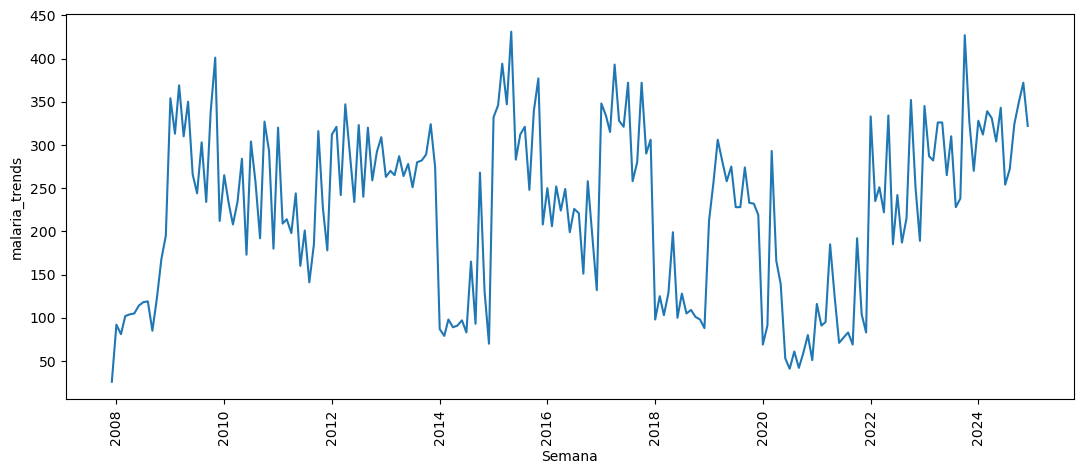

In [7]:
#Visualización de datos mensuales
plt.figure(figsize=(13,5))
sns.lineplot(data=data,x=data.index,y=data.malaria_trends)
plt.xticks(rotation=90)
plt.show()

In [8]:
#Exportamos los datos relativos a las búsquedas de malaria en España
data.to_csv('malaria_trends.csv',index=True,encoding='utf-8')